In [65]:

path = '/home/apolo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [66]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import dabest

from statsmodels.stats.proportion import proportions_chisquare

%matplotlib widget

import helper_functions as hf


In [67]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


In [68]:

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [69]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [70]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_Abundance_Overall.csv'
df = pd.read_csv(filename)

shank_mask = (df['shank_distance'] == 0.0) | (df['shank_distance'] == 400.0)
side_mask = df['shank_side'] == 'right'
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*side_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df = df.reset_index(drop=True)
df

,rat,session,shank_side,shank_distance,ripple_abundance
0,Ach,Achilles_10252013,left,0.0,0.500833
1,Ach,Achilles_10252013,left,200.0,0.500000
2,Ach,Achilles_10252013,left,400.0,0.488611
3,Ach,Achilles_10252013,left,600.0,0.481111
4,Ach,Achilles_10252013,left,800.0,0.479167
...,...,...,...,...,...
85,Gat,Gatsby_08282013,left,1200.0,0.485556
86,Gat,Gatsby_08282013,right,800.0,0.588056
87,Gat,Gatsby_08282013,right,1000.0,0.589444
88,Gat,Gatsby_08282013,right,1200.0,0.622500


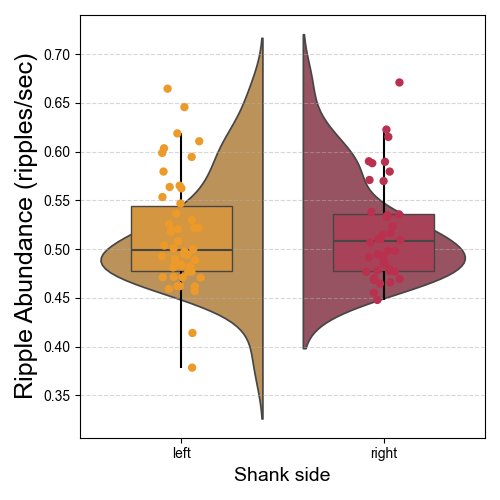

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  rawdata_plot = sns.swarmplot(data=plot_data, x=xvar, y=yvar,
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:438: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rawdata_axes.set_xticklabels(ticks_with_counts)
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:559: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean().loc[current_contr

Text(0.5, 0.98, 'hedges_g = 0.08230101604454776')

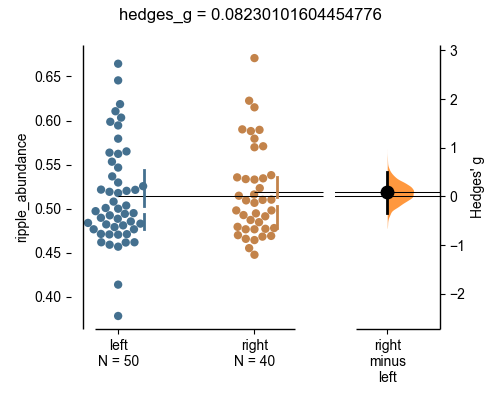

In [71]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"left": "#ec9a29","right":"#b9314f"}

sns.stripplot(data=df, x="shank_side",hue="shank_side",y="ripple_abundance", order=["left", "right"],
              palette=my_pal,size=6,legend=False,alpha=1)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='shank_side', hue="shank_side", y='ripple_abundance',
            order=["left", "right"], showfliers=False, showcaps=False,fill=True,legend=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

sns.violinplot(data=df,x='shank_side', hue="shank_side",order=["left", "right"], y='ripple_abundance',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5,legend=False)

plt.ylabel('Ripple Abundance (ripples/sec)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)

# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_2/')
fig_name = 'Figure_Ripple_Abundance_Overall.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


# fig_name = 'Figure_Ripple_Abundance_Overall_dabest.svg'
# # Load the above data into `dabest`.
df_dabest = dabest.load(data=df, x="shank_side", y="ripple_abundance",idx=("left", "right"))
# # Produce a Cumming estimation plot.
df_dabest.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=True)
plt.suptitle('hedges_g = ' + str(df_dabest.hedges_g.statistical_tests.difference[0]))
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)



In [22]:
df

,rat,session,shank_side,shank_distance,ripple_abundance
0,Ach,Achilles_10252013,left,0.0,0.500833
1,Ach,Achilles_10252013,left,200.0,0.500000
2,Ach,Achilles_10252013,left,400.0,0.488611
3,Ach,Achilles_10252013,left,600.0,0.481111
4,Ach,Achilles_10252013,left,800.0,0.479167
...,...,...,...,...,...
85,Gat,Gatsby_08282013,left,1200.0,0.485556
86,Gat,Gatsby_08282013,right,800.0,0.588056
87,Gat,Gatsby_08282013,right,1000.0,0.589444
88,Gat,Gatsby_08282013,right,1200.0,0.622500


In [45]:
# # df_dabest.hedges_g.results
df_dabest.hedges_g.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,left,right,50,40,Hedges' g,False,0.082301,95,-0.329859,0.495628,0.6982,0.693366,-0.39561,0.696509,-0.391317,0.720869,955.5


In [46]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_abundance ~ C(shank_side, Treatment(reference='left'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                            Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           ripple_abundance
No. Observations:            90                Method:                       REML            
No. Groups:                  4                 Scale:                        0.0015          
Min. group size:             9                 Log-Likelihood:               148.7057        
Max. group size:             36                Converged:                    Yes             
Mean group size:             22.5                                                            
---------------------------------------------------------------------------------------------
                                                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                           0.514    0.020 25.115 0.000  0.474  

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [48]:

os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_Abundance_Threshold.csv'
df = pd.read_csv(filename)
df

shank_mask = (df['shank_distance'] == 0.0) | (df['shank_distance'] == 400.0)
side_mask = df['shank_side'] == 'right'
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*side_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df = df.reset_index(drop=True)
df

,rat,session,shank_side,shank_distance,ripple_abundance,ripple_threshold_level
0,Ach,Achilles_10252013,left,0.0,0.500833,2
1,Ach,Achilles_10252013,left,0.0,0.299444,3
2,Ach,Achilles_10252013,left,0.0,0.174722,4
3,Ach,Achilles_10252013,left,0.0,0.098611,5
4,Ach,Achilles_10252013,left,0.0,0.045000,6
...,...,...,...,...,...,...
805,Gat,Gatsby_08282013,right,1400.0,0.007222,6
806,Gat,Gatsby_08282013,right,1400.0,0.001389,7
807,Gat,Gatsby_08282013,right,1400.0,0.000556,8
808,Gat,Gatsby_08282013,right,1400.0,0.000000,9


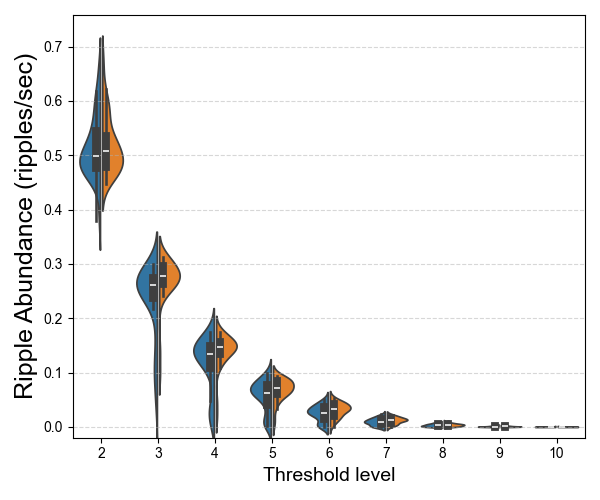

In [34]:

# testing colors
hue_sep = 0.3

plt.close('all')
# plt.figure(figsize=(7,5))
plt.figure(figsize=(6,5))

my_pal ={"left": "#ec9a29","right":"#b9314f"}



sns.violinplot(data=df,x='ripple_threshold_level',hue="shank_side",y='ripple_abundance',split=True,density_norm='count',gap = 0.1)
# sns.pointplot(data=df,x='ripple_threshold_level',hue="shank_side",y='ripple_abundance',estimator='median',
#               errorbar=("pi",75), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10,dodge=hue_sep)

plt.ylabel('Ripple Abundance (ripples/sec)',fontsize=18)
plt.xlabel('Threshold level',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=-0.02)

plt.tight_layout()
os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_Abundance_Threshold'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [35]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_abundance ~ C(shank_side, Treatment(reference='left'))*ripple_threshold_level"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                                        Mixed Linear Model Regression Results
Model:                                MixedLM                   Dependent Variable:                   ripple_abundance
No. Observations:                     810                       Method:                               REML            
No. Groups:                           4                         Scale:                                0.0096          
Min. group size:                      81                        Log-Likelihood:                       709.3046        
Max. group size:                      324                       Converged:                            Yes             
Mean group size:                      202.5                                                                           
----------------------------------------------------------------------------------------------------------------------
                                                                           Coef.  Std.Err

In [38]:
50*9 + 40*9

810

In [40]:
result.pvalues

Intercept                                                                      8.981824e-38
C(shank_side, Treatment(reference='left'))[T.right]                            1.550132e-01
ripple_threshold_level                                                        8.331607e-177
C(shank_side, Treatment(reference='left'))[T.right]:ripple_threshold_level     2.741377e-01
rat Var                                                                                 NaN
session Var                                                                             NaN
dtype: float64

In [74]:

sessions = ['Achilles_10252013', 
            'Achilles_11012013',
            'Buddy_06272013',
            'Cicero_09012014',
            'Cicero_09102014',
            'Cicero_09172014',
            'Gatsby_08022013',
            'Gatsby_08282013']

os.chdir(tables_path + '/figure_2/')

df = pd.DataFrame()
ripple_freq_left = []
ripple_freq_right = []
for session in sessions:
    
    filename = 'Figure_Ripple_Frequency_Distribution_' + session + '.npy'
    df_pre = np.load(filename,allow_pickle=True).item()
    df_pre = pd.DataFrame(df_pre)
        
    ripple_mean_frequency = []
    for ii in range(df_pre['ripple_frequency'].shape[0]):
        ripple_mean_frequency.append(np.nanmean(df_pre['ripple_frequency'][ii]))
    df_pre['ripple_frequency'] = ripple_mean_frequency
    df = pd.concat([df,df_pre])

df = df.rename(columns={'ripple_frequency': 'ripple_mean_frequency'})


shank_mask = (df['shank_distance'] == 0.0) | (df['shank_distance'] == 400.0)
side_mask = df['shank_side'] == 'right'
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*side_mask*rat_mask)]

# # Do this to use in the linear mixed model formula with varying intercepts
# # (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df = df.reset_index(drop=True)
df

,rat,session,shank_side,shank_distance,ripple_mean_frequency
0,Ach,Achilles_10252013,left,0.0,151.859124
1,Ach,Achilles_10252013,left,200.0,151.642222
2,Ach,Achilles_10252013,left,400.0,152.494599
3,Ach,Achilles_10252013,left,600.0,153.863741
4,Ach,Achilles_10252013,left,800.0,154.871884
...,...,...,...,...,...
85,Gat,Gatsby_08282013,left,1200.0,140.310069
86,Gat,Gatsby_08282013,right,800.0,133.783656
87,Gat,Gatsby_08282013,right,1000.0,134.951932
88,Gat,Gatsby_08282013,right,1200.0,133.750112


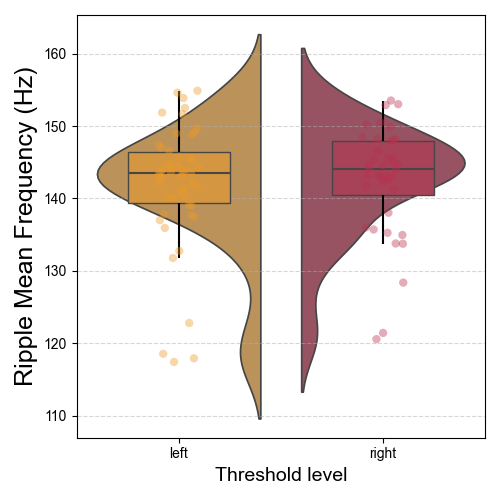

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  rawdata_plot = sns.swarmplot(data=plot_data, x=xvar, y=yvar,
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:438: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rawdata_axes.set_xticklabels(ticks_with_counts)
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:559: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean().loc[current_contr

Text(0.5, 0.98, 'hedges_g = 0.07483306226365313')

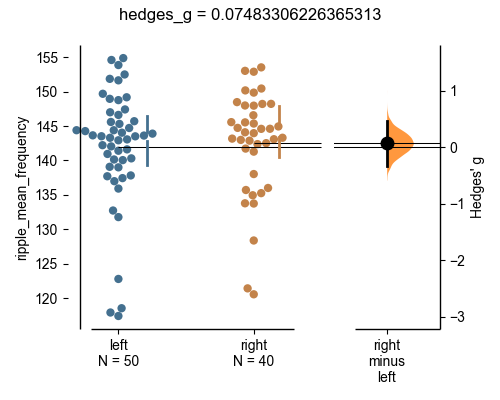

In [75]:
hue_sep = 0.3

plt.close('all')
plt.figure(figsize=(5,5))

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

my_pal ={"left": "#ec9a29","right":"#b9314f"}

sns.stripplot(data=df, x="shank_side",hue="shank_side",y="ripple_mean_frequency", order=["left", "right"],
              palette=my_pal,size=6,legend=False,alpha=0.4)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_mean_frequency', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)
box = sns.boxplot(data=df, x='shank_side', hue="shank_side", y='ripple_mean_frequency',
            order=["left", "right"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette


sns.violinplot(data=df,x='shank_side', hue="shank_side",order=["left", "right"], y='ripple_mean_frequency',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5)

plt.ylabel('Ripple Mean Frequency (Hz)',fontsize=18)
plt.xlabel('Threshold level',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
# plt.ylim(bottom=-0.02)

plt.tight_layout()
os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_Mean_Frequency'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


fig_name = 'Figure_Ripple_Mean_Frequency_dabest.svg'
# Load the above data into `dabest`.
df_dabest = dabest.load(data=df, x="shank_side",y="ripple_mean_frequency",idx=("left", "right"))
# Produce a Cumming estimation plot.
df_dabest.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=True)
plt.suptitle('hedges_g = ' + str(df_dabest.hedges_g.statistical_tests.difference[0]))
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)



In [78]:
ripple_freq_left = np.array(df.ripple_mean_frequency[df.shank_side == 'left'])
ripple_freq_right = np.array(df.ripple_mean_frequency[df.shank_side == 'right'])

import pingouin as pg

tost_stats = pg.tost(ripple_freq_left, ripple_freq_right,bound=4)
tost_stats


,bound,dof,pval
TOST,4,88,0.026336


In [59]:
stats.ttest_ind(ripple_freq_left, ripple_freq_right)

TtestResult(statistic=-0.35580898884379747, pvalue=0.7228351515642282, df=88.0)

In [24]:
df_dabest.hedges_g

DABEST v2024.03.29
                  
Good afternoon!
The current time is Wed Sep 25 13:02:12 2024.

The unpaired Hedges' g between left and right is 0.0748 [95%CI -0.337, 0.466].
The p-value of the two-sided permutation t-test is 0.733, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.hedges_g.statistical_tests`

In [20]:
df_dabest.hedges_g.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,left,right,50,40,Hedges' g,None,0.074833,95,-0.336947,0.46598,0.7332,0.71932,-0.360536,0.722835,-0.355809,0.646393,943.0


In [25]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_mean_frequency ~ C(shank_side, Treatment(reference='left'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                              Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           ripple_mean_frequency
No. Observations:           90                Method:                       REML                 
No. Groups:                 4                 Scale:                        27.5159              
Min. group size:            9                 Log-Likelihood:               -282.7323            
Max. group size:            36                Converged:                    Yes                  
Mean group size:            22.5                                                                 
-------------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

In [79]:
sessions = ['Achilles_10252013', 
            'Achilles_11012013',
            'Buddy_06272013',
            'Cicero_09012014',
            'Cicero_09102014',
            'Cicero_09172014',
            'Gatsby_08022013',
            'Gatsby_08282013']


os.chdir(tables_path + '/figure_2/')

df = pd.DataFrame()
ripple_freq_left = []
ripple_freq_right = []
for session in sessions:
    
    filename = 'Figure_Ripple_Frequency_Distribution_' + session + '.npy'
    df_pre = np.load(filename,allow_pickle=True).item()
    # df = pd.concat([df,df_pre])

    df = pd.DataFrame(df_pre)
    
    left_idx = df['shank_side'] == 'left'
    ripple_freq_left.append(np.concatenate(np.array(df['ripple_frequency'][left_idx])))
    right_idx = df['shank_side'] == 'right'
    ripple_freq_right.append(np.concatenate(np.array(df['ripple_frequency'][right_idx])))

ripple_freq_left = np.concatenate(ripple_freq_left)
ripple_freq_right = np.concatenate(ripple_freq_right)


In [13]:
max_val

0.01903385734572361

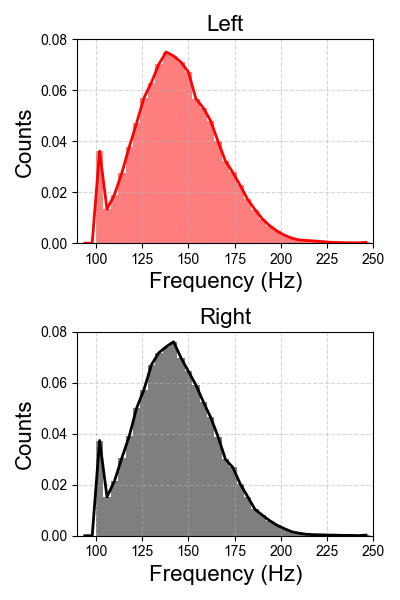

In [80]:

bar_width = 4
counts_left,bins = np.histogram(ripple_freq_left,bins=np.arange(90,250,bar_width))
counts_right,bins = np.histogram(ripple_freq_right,bins=np.arange(90,250,bar_width))

center_bins = bins[0:-1] + np.diff(bins)

max_val = np.nanmax([counts_right,counts_left])
max_val + max_val*0.02
# max_val = 3500

plt.close('all')

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

# plt.figure(figsize=(10,4))
plt.figure(figsize=(4,6))

plt.subplot(2,1,1)
plt.plot(center_bins,counts_left/np.sum(counts_left),color='red',linewidth=2)
plt.bar(center_bins,counts_left/np.sum(counts_left),color='red',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Left',fontsize=16)
plt.xlim([90,250])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.08])
plt.ylabel('Counts',fontsize=16)
plt.xlabel('Frequency (Hz)',fontsize=16)

plt.subplot(2,1,2)
plt.plot(center_bins,counts_right/np.sum(counts_right),color='black',linewidth=2)
plt.bar(center_bins,counts_right/np.sum(counts_right), color='black',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Right',fontsize=16)
plt.xlim([90,250])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.08])
plt.ylabel('Counts',fontsize=16)
plt.xlabel('Frequency (Hz)',fontsize=16)
plt.tight_layout()

os.chdir(figures_path + '/figure_2/')
fig_name = 'Figure_Ripple_Frequency_Distribution'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [81]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_InterRippleInterval_OverallMean.csv'
df = pd.read_csv(filename)
df

shank_mask = (df['shank_distance'] == 0.0) | (df['shank_distance'] == 400.0)
side_mask = df['shank_side'] == 'right'
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*side_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df = df.reset_index(drop=True)
df

,rat,session,shank_side,shank_distance,ripple_iri
0,Ach,Achilles_10252013,left,0.0,1.994846
1,Ach,Achilles_10252013,left,200.0,2.000216
2,Ach,Achilles_10252013,left,400.0,2.044720
3,Ach,Achilles_10252013,left,600.0,2.078295
4,Ach,Achilles_10252013,left,800.0,2.086729
...,...,...,...,...,...
85,Gat,Gatsby_08282013,left,1200.0,2.056022
86,Gat,Gatsby_08282013,right,800.0,1.699473
87,Gat,Gatsby_08282013,right,1000.0,1.695463
88,Gat,Gatsby_08282013,right,1200.0,1.606214


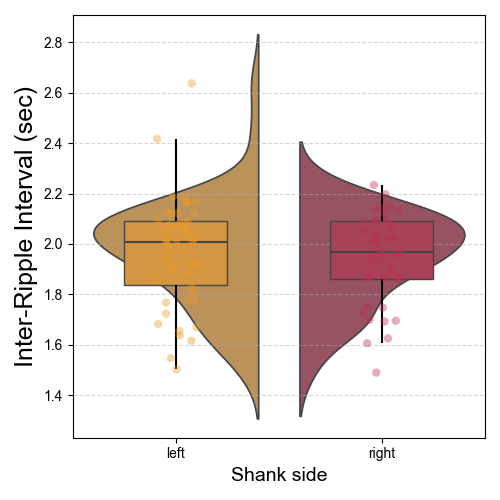

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  rawdata_plot = sns.swarmplot(data=plot_data, x=xvar, y=yvar,
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:438: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rawdata_axes.set_xticklabels(ticks_with_counts)
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:559: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean().loc[current_contr

Text(0.5, 0.98, 'hedges_g = -0.11411513763536263')

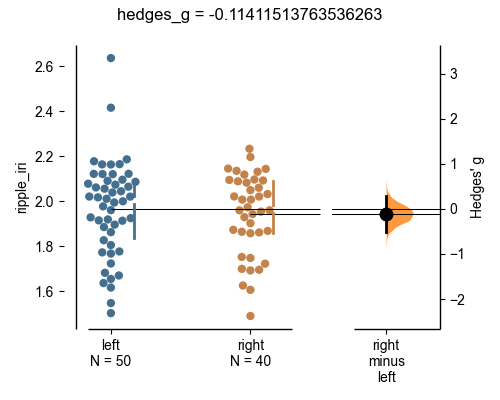

In [82]:
# testing colors
hue_sep = 0.3

plt.close('all')
plt.figure(figsize=(5,5))

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

my_pal ={"left": "#ec9a29","right":"#b9314f"}

sns.stripplot(data=df, x="shank_side",hue="shank_side",y="ripple_iri", order=["left", "right"],
              palette=my_pal,size=6,legend=False,alpha=0.4)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_iri', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0,linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

box = sns.boxplot(data=df, x='shank_side', hue="shank_side", y='ripple_iri',
            order=["left", "right"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette


sns.violinplot(data=df,x='shank_side', hue="shank_side",order=["left", "right"], y='ripple_iri',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5)

plt.ylabel('Inter-Ripple Interval (sec)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
# plt.ylim(bottom=-0.02)

plt.tight_layout()
os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_IRI'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)

fig_name = 'Figure_Ripple_IRI_dabest.svg'
# Load the above data into `dabest`.
df_dabest = dabest.load(data=df, x="shank_side",y="ripple_iri",idx=("left", "right"))
# Produce a Cumming estimation plot.
df_dabest.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=True)
plt.suptitle('hedges_g = ' + str(df_dabest.hedges_g.statistical_tests.difference[0]))
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)


In [87]:
ripple_iri_left = np.array(df.ripple_iri[df.shank_side == 'left'])
ripple_iri_right = np.array(df.ripple_iri[df.shank_side == 'right'])

import pingouin as pg

tost_stats = pg.tost(ripple_iri_left, ripple_iri_right,bound=0.1)
tost_stats


,bound,dof,pval
TOST,0.1,88,0.035407


In [31]:
df_dabest.hedges_g

DABEST v2024.03.29
                  
Good afternoon!
The current time is Wed Sep 25 13:11:00 2024.

The unpaired Hedges' g between left and right is -0.114 [95%CI -0.514, 0.29].
The p-value of the two-sided permutation t-test is 0.598, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.hedges_g.statistical_tests`

In [33]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_iri ~ C(shank_side, Treatment(reference='left'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())



                            Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             ripple_iri
No. Observations:               90                  Method:                         REML      
No. Groups:                     4                   Scale:                          0.0221    
Min. group size:                9                   Log-Likelihood:                 31.1825   
Max. group size:                36                  Converged:                      Yes       
Mean group size:                22.5                                                          
----------------------------------------------------------------------------------------------
                                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------
Intercept                                            1.966    0.067 29.249 0.00

In [6]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_InterRippleInterval_Distribution.npy'
output = np.load(filename,allow_pickle=True).item()


In [7]:

ripple_iri_left = []
ripple_iri_right = []
for rr in range(len(output['ripple_iri'])):
    if output['shank_side'][rr] == 'left':
        ripple_iri_left.append(output['ripple_iri'][rr])
    else:
        ripple_iri_right.append(output['ripple_iri'][rr])
    
ripple_iri_right = np.concatenate(ripple_iri_right)
ripple_iri_left = np.concatenate(ripple_iri_left)


In [8]:

bar_width = 0.05
counts_left,bins = np.histogram(ripple_iri_left,bins=np.arange(0,3,bar_width),density=False)
counts_right,bins = np.histogram(ripple_iri_right,bins=np.arange(0,3,bar_width),density=False)

center_bins = bins[0:-1] + np.diff(bins)

max_val = np.nanmax([counts_right,counts_left])
max_val + max_val*0.02


9199.38

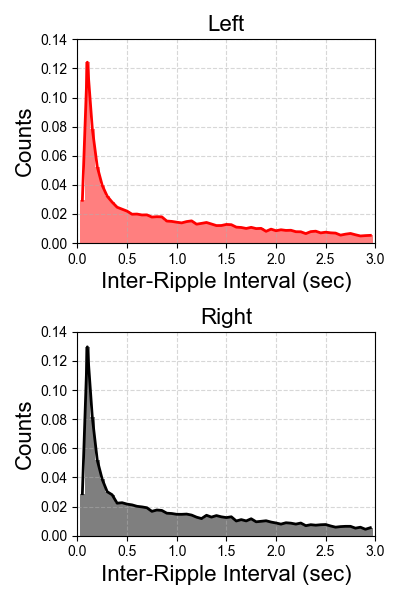

In [10]:
plt.close('all')

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

plt.figure(figsize=(4,6))
plt.subplot(2,1,1)

plt.plot(center_bins,counts_left/np.sum(counts_left),color='red',linewidth=2)
plt.bar(center_bins,counts_left/np.sum(counts_left),color='red',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Left',fontsize=16)
plt.xlim([0,3])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.14])
plt.ylabel('Counts',fontsize=16)
plt.xlabel('Inter-Ripple Interval (sec)',fontsize=16)


plt.subplot(2,1,2)
plt.plot(center_bins,counts_right/np.sum(counts_right),color='black',linewidth=2)
plt.bar(center_bins,counts_right/np.sum(counts_right),color='black',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Right',fontsize=16)
plt.xlim([0,3])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.14])
plt.ylabel('Counts',fontsize=16)
plt.xlabel('Inter-Ripple Interval (sec)',fontsize=16)

plt.tight_layout()

os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_IRI_Distribution.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [88]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_NumberOfCycles.csv'
df = pd.read_csv(filename)

shank_mask = (df['shank_distance'] == 0.0) | (df['shank_distance'] == 400.0)
side_mask = df['shank_side'] == 'right'
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*side_mask*rat_mask)]


# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df = df.reset_index(drop=True)
df

,rat,session,shank_side,shank_distance,ripple_cycles
0,Ach,Achilles_10252013,left,0.0,7.051026
1,Ach,Achilles_10252013,left,200.0,6.968333
2,Ach,Achilles_10252013,left,400.0,7.031836
3,Ach,Achilles_10252013,left,600.0,7.175520
4,Ach,Achilles_10252013,left,800.0,7.153623
...,...,...,...,...,...
85,Gat,Gatsby_08282013,left,1200.0,6.231121
86,Gat,Gatsby_08282013,right,800.0,6.341521
87,Gat,Gatsby_08282013,right,1000.0,6.426956
88,Gat,Gatsby_08282013,right,1200.0,6.486390


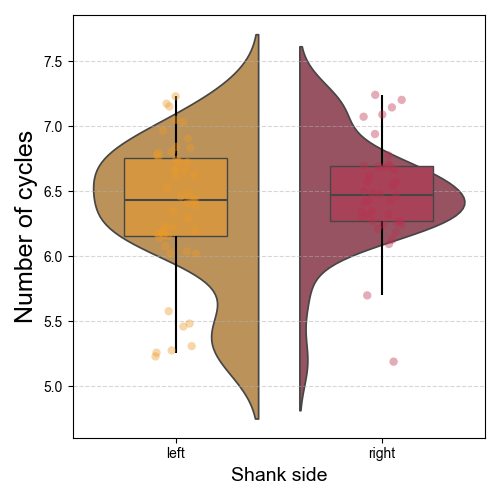

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  rawdata_plot = sns.swarmplot(data=plot_data, x=xvar, y=yvar,
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:438: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rawdata_axes.set_xticklabels(ticks_with_counts)
/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/dabest/plotter.py:559: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean().loc[current_contr

Text(0.5, 0.98, 'hedges_g = 0.23278948385621528')

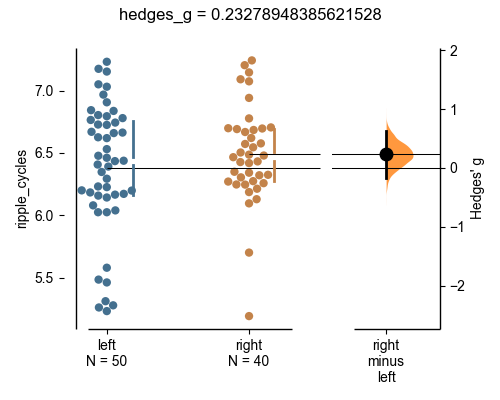

In [89]:
# testing colors
hue_sep = 0.3

plt.close('all')
plt.figure(figsize=(5,5))

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

my_pal ={"left": "#ec9a29","right":"#b9314f"}

sns.stripplot(data=df, x="shank_side",hue="shank_side",y="ripple_cycles", order=["left", "right"],
              palette=my_pal,size=6,legend=False,alpha=0.4)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_cycles', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

box = sns.boxplot(data=df, x='shank_side', hue="shank_side", y='ripple_cycles',
            order=["left", "right"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette


sns.violinplot(data=df,x='shank_side', hue="shank_side",order=["left", "right"], y='ripple_cycles',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5)

plt.ylabel('Number of cycles',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
# plt.ylim(bottom=-0.02)

plt.tight_layout()
os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_Number_of_Cycles'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


fig_name = 'Figure_Ripple_Number_of_Cycles_dabest.svg'
# Load the above data into `dabest`.
df_dabest = dabest.load(data=df, x="shank_side",y="ripple_cycles",idx=("left", "right"))
# Produce a Cumming estimation plot.
df_dabest.hedges_g.plot(group_summaries = 'median_quartiles',float_contrast=True)
plt.suptitle('hedges_g = ' + str(df_dabest.hedges_g.statistical_tests.difference[0]))
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)


In [94]:
ripple_cycles_left = np.array(df.ripple_cycles[df.shank_side == 'left'])
ripple_cycles_right = np.array(df.ripple_cycles[df.shank_side == 'right'])

import pingouin as pg

tost_stats = pg.tost(ripple_cycles_left, ripple_cycles_right,bound=0.3)
tost_stats

,bound,dof,pval
TOST,0.3,88,0.029641


In [16]:
df_dabest.hedges_g.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,left,right,50,40,Hedges' g,None,0.232789,95,-0.167787,0.627027,0.2764,0.256371,-1.142467,0.271377,-1.106845,0.447722,906.0


In [15]:
df_dabest.hedges_g

DABEST v2024.03.29
                  
Good afternoon!
The current time is Wed Sep 25 17:02:07 2024.

The unpaired Hedges' g between left and right is 0.233 [95%CI -0.168, 0.627].
The p-value of the two-sided permutation t-test is 0.276, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.hedges_g.statistical_tests`

In [14]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_cycles ~ C(shank_side, Treatment(reference='left'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())



                            Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            ripple_cycles
No. Observations:             90                 Method:                        REML         
No. Groups:                   4                  Scale:                         0.1040       
Min. group size:              9                  Log-Likelihood:                -36.4012     
Max. group size:              36                 Converged:                     Yes          
Mean group size:              22.5                                                           
---------------------------------------------------------------------------------------------
                                                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                           6.404    0.193 33.222 0.000  6.026  

In [48]:
sessions = ['Achilles_10252013', 
            'Achilles_11012013',
            'Buddy_06272013',
            'Cicero_09012014',
            'Cicero_09102014',
            'Cicero_09172014',
            'Gatsby_08022013',
            'Gatsby_08282013']
# sessions = ['Achilles_10252013']

os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_NumberOfCycles_Distribution.npy'
df = np.load(filename,allow_pickle=True).item()
df = pd.DataFrame(df)

ripple_ncycles_left = []
ripple_ncycles_right = []
for session in sessions:
    
    ses_idx = df['session'] == session
    left_idx = df['shank_side'] == 'left'
    ripple_ncycles_left.append(np.concatenate(np.array(df['ripple_cycles'][ses_idx*left_idx])))
    
    right_idx = df['shank_side'] == 'right'
    ripple_ncycles_right.append(np.concatenate(np.array(df['ripple_cycles'][ses_idx*right_idx])))

ripple_ncycles_left = np.concatenate(ripple_ncycles_left)
ripple_ncycles_right = np.concatenate(ripple_ncycles_right)


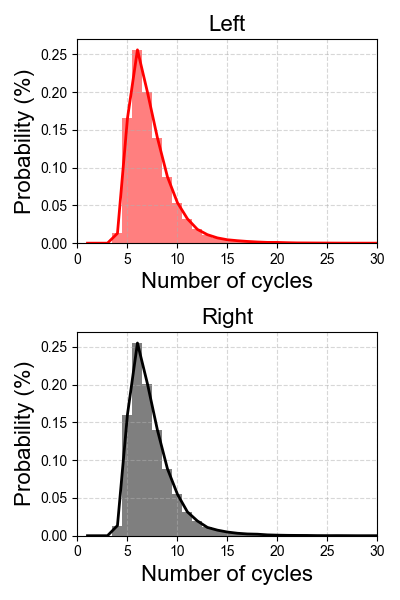

ClipPath elements deleted.
File saved.


In [53]:

bar_width = 1
counts_left,bins = np.histogram(ripple_ncycles_left,bins=np.arange(0,30+bar_width,bar_width))
counts_right,bins = np.histogram(ripple_ncycles_right,bins=np.arange(0,30+bar_width,bar_width))

center_bins = bins[0:-1] + np.diff(bins)

max_val = np.nanmax([counts_right,counts_left])
max_val + max_val*0.02
# max_val = 2500

plt.close('all')

plt.rcParams['svg.fonttype'] = 'none' #when saving svg, keep text as text

plt.figure(figsize=(4,6))
plt.subplot(2,1,1)
plt.plot(center_bins,counts_left/np.sum(counts_left),color='red',linewidth=2)
plt.bar(center_bins,counts_left/np.sum(counts_left),color='red',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Left',fontsize=16)
plt.xlim([0,30])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.27])
plt.ylabel('Probability (%)',fontsize=16)
plt.xlabel('Number of cycles',fontsize=16)

plt.subplot(2,1,2)
plt.plot(center_bins,counts_right/np.sum(counts_right),color='black',linewidth=2)
plt.bar(center_bins,counts_right/np.sum(counts_right), color='black',width = bar_width,alpha=0.5)
plt.grid(linestyle='--',alpha=0.5)
plt.title('Right',fontsize=16)
plt.xlim([0,30])
# plt.ylim([0,max_val + max_val*0.1])
plt.ylim([0,0.27])
plt.ylabel('Probability (%)',fontsize=16)
plt.xlabel('Number of cycles',fontsize=16)

plt.tight_layout()

os.chdir(figures_path + '/figure_2/')

fig_name = 'Figure_Ripple_NumberOfCycles_Distribution'
plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
hf.delete_clip_path(fig_name)

